SISTEMA DE PREDICCIÓN DE ACCIONES - VERSIÓN COMPLETA

1. CARGA Y PREPARACIÓN DE DATOS
✓ Dataset cargado: 6679 filas, 64 columnas
✓ Rango de fechas: 1999-05-19 a 2025-12-04
✓ Índice establecido: 1999-05-19 a 2025-12-04

✓ Features disponibles para clasificación: 15/15
  ['Close', 'Volume', 'RSI', 'MA20', 'MA200']...

2. PARTE A: CLASIFICACIÓN BINARIA
Objetivo: Predecir si el precio subirá >2% en 30 días
✓ Target creado: 'Target_Clasificacion'
  Distribución: {1: 3815, 0: 2864}
  Porcentaje positivos: 57.12%

✓ Datos limpiados para clasificación:
  Filas totales: 6679
  Positivos: 3815 (57.12%)

✓ División temporal para clasificación:
  Train: 1999-05-19 a 2020-08-11 (5343 días)
  Test:  2020-08-12 a 2025-12-04 (1336 días)

✓ Modelo de clasificación entrenado: LogisticRegression
✓ Accuracy en test: 58.23%

3. PARTE B: FORECASTING DE PRECIO (365 DÍAS)
Objetivo: Predecir precio exacto 365 días en el futuro

Preparando datos para forecasting de 365 días...
✓ Features para forecasting: ['Clo

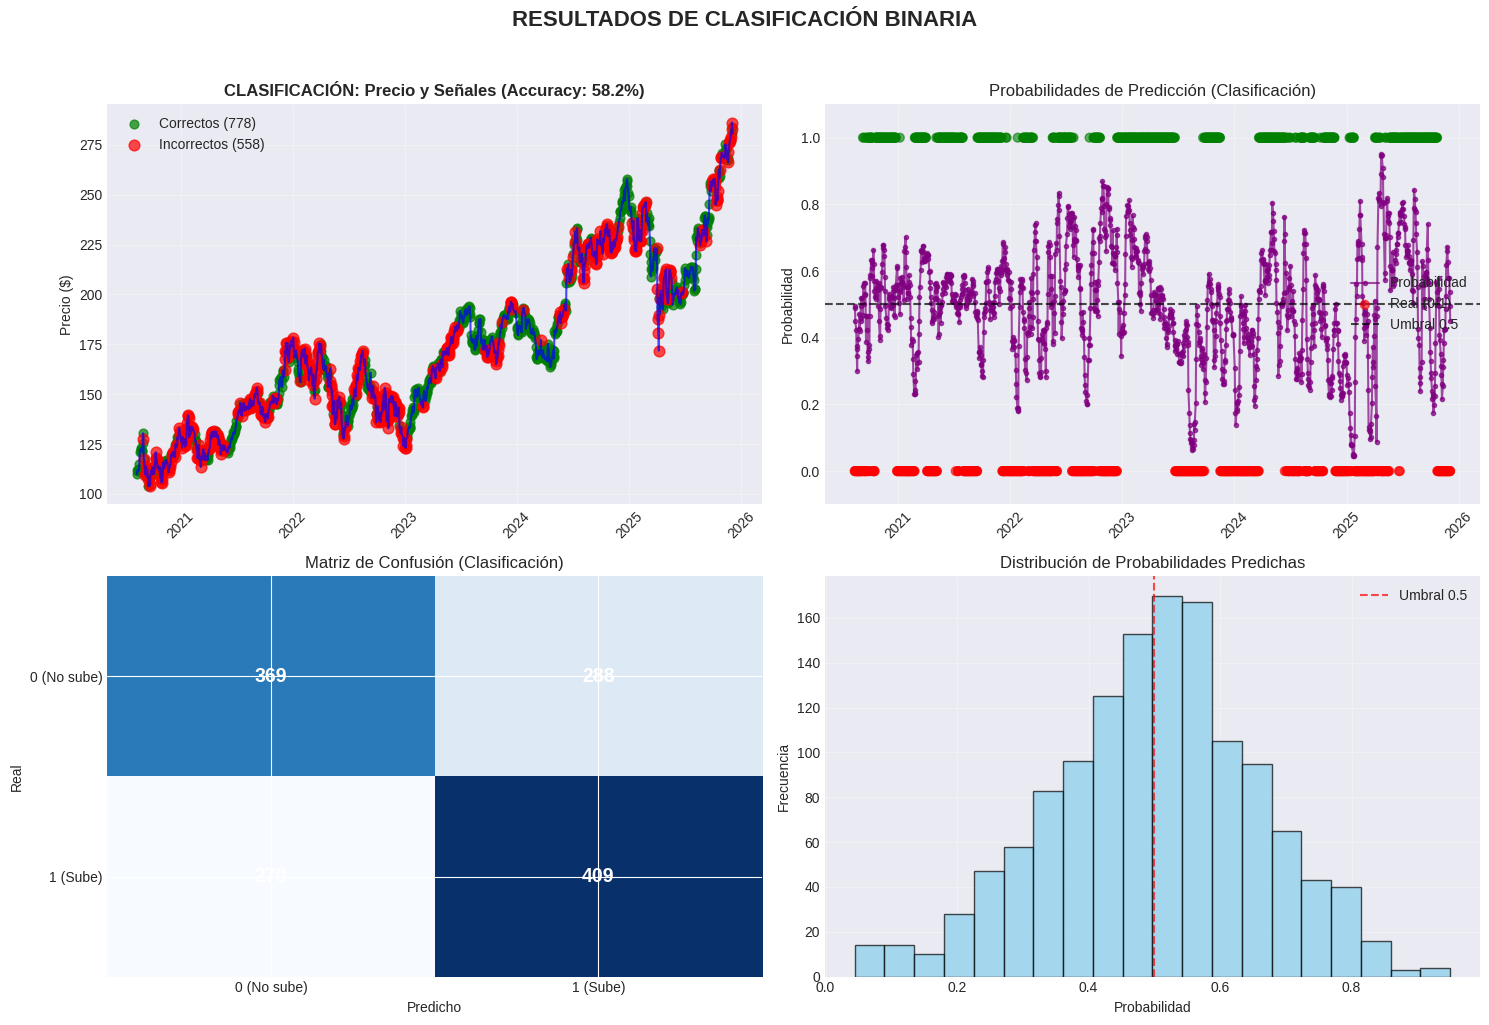


Generando gráfica de forecasting (SOLO período de test)...
Rango de fechas del test: 2023-01-09 00:00:00 a 2024-06-21 00:00:00
Número de días: 365

Configurando eje X para 365 días...
Mostrando fechas por meses (intervalo: 12 meses)


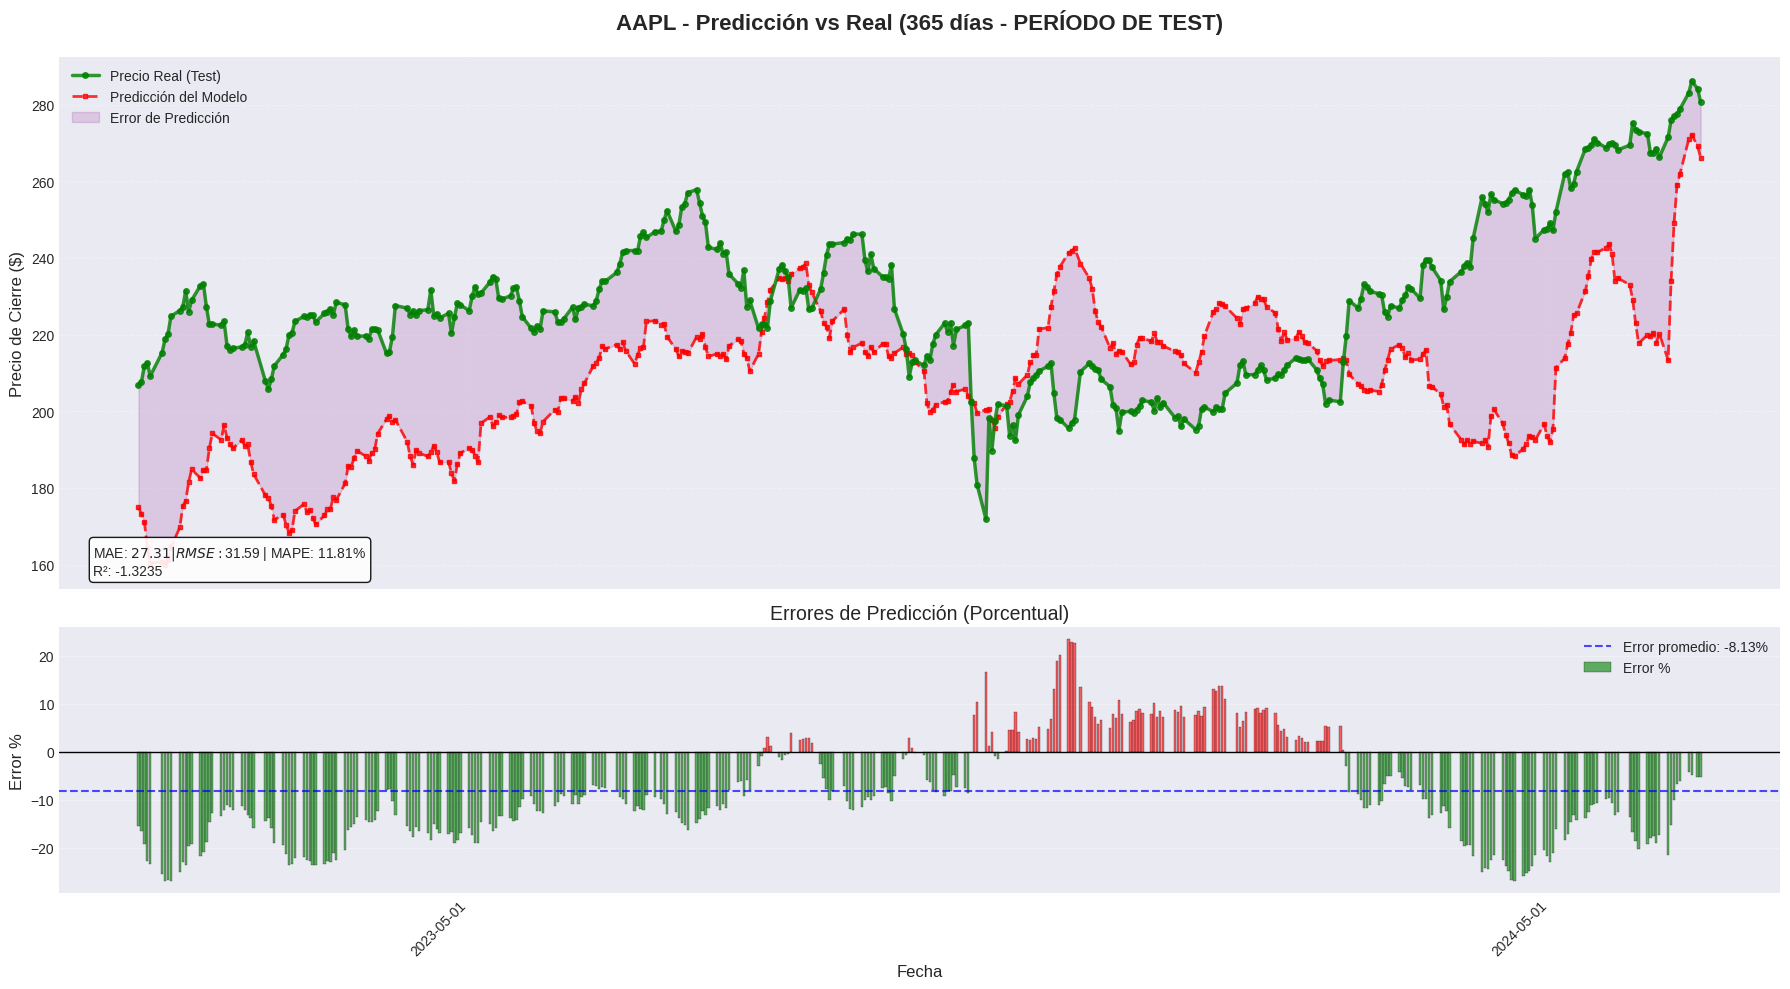


📅 INFORMACIÓN DETALLADA DE FECHAS:
Primera fecha: 2023-01-09 00:00:00
Última fecha: 2024-06-21 00:00:00
Total de días hábiles: 365
Total de semanas: 52
Total de meses: 12.0

📊 FECHAS CLAVE DEL PERÍODO DE TEST:
--------------------------------------------------
📌 Inicio: 2023-01-09
📌 Fin: 2024-06-21
  2023-01-09: Real=$206.74, Pred=$174.94, Error=-15.4%
  2023-02-22: Real=$205.83, Pred=$177.33, Error=-13.8%
  2023-04-05: Real=$219.45, Pred=$197.09, Error=-10.2%
  2023-05-18: Real=$228.81, Pred=$202.31, Error=-11.6%
  2023-07-03: Real=$246.84, Pred=$223.64, Error=-9.4%
  2023-08-15: Real=$238.28, Pred=$234.46, Error=-1.6%
  2023-09-27: Real=$208.97, Pred=$215.15, Error=3.0%
  2023-11-08: Real=$208.57, Pred=$214.71, Error=2.9%
  2023-12-21: Real=$201.03, Pred=$218.11, Error=8.5%
  2024-02-06: Real=$213.70, Pred=$220.72, Error=3.3%
  2024-03-20: Real=$239.55, Pred=$215.99, Error=-9.8%
  2024-05-02: Real=$247.21, Pred=$195.38, Error=-21.0%
  2024-06-14: Real=$278.85, Pred=$261.90, Error=-6

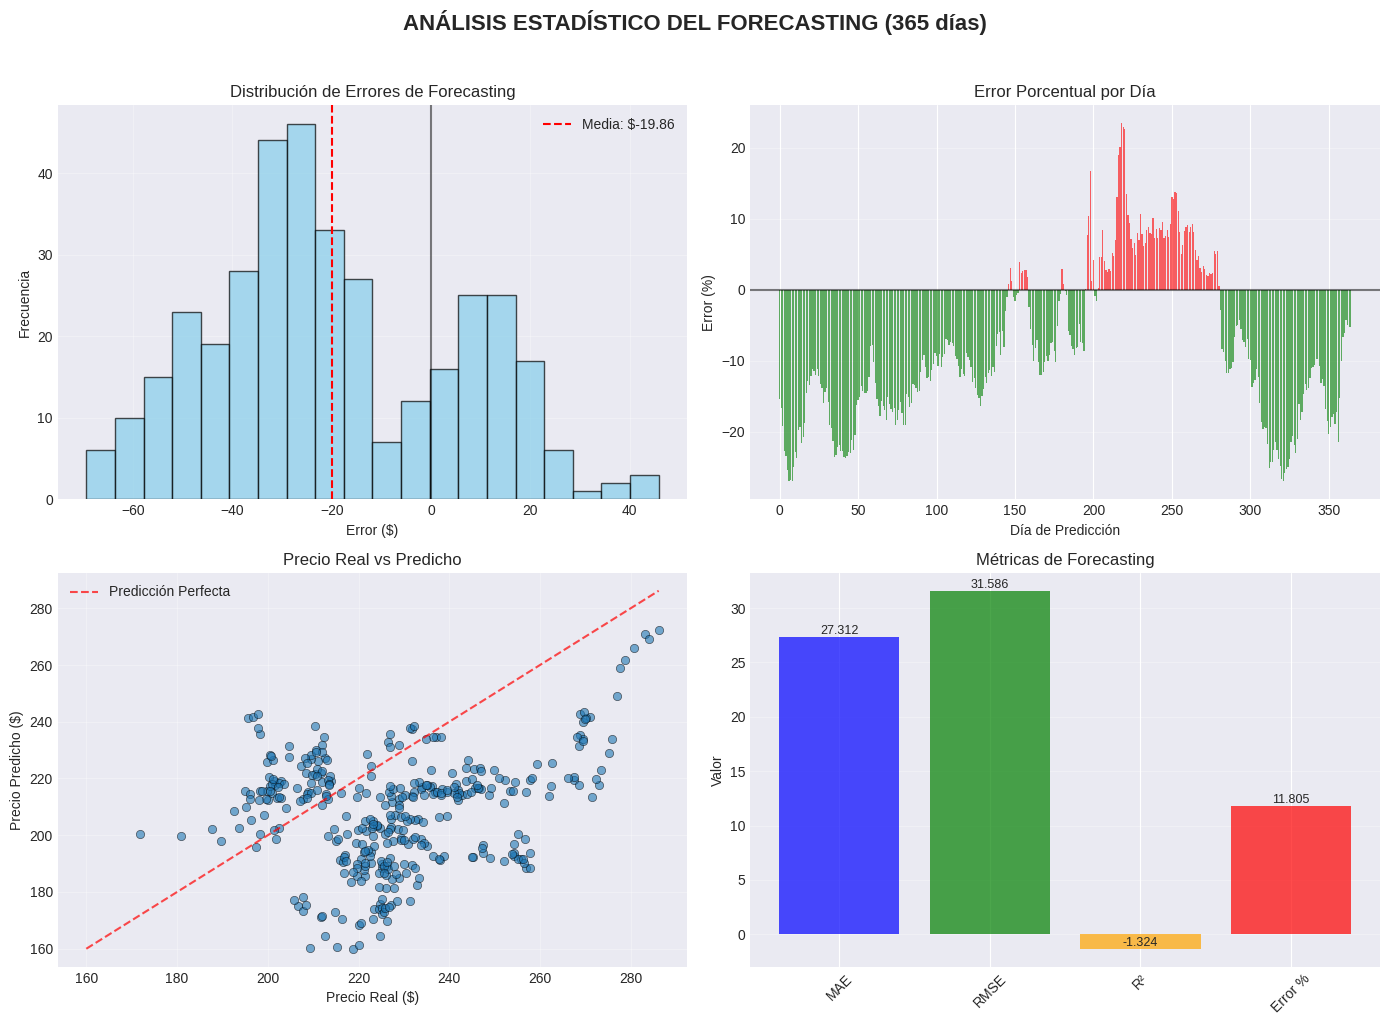


RESUMEN EJECUTIVO COMPLETO

📅 INFORMACIÓN GENERAL:
  • Período total: 6679 días
  • Rango: 1999-05-19 a 2025-12-04
  • Precio actual (final): $280.70

📊 PARTE A: CLASIFICACIÓN BINARIA (30 días):
  • Objetivo: Predecir si sube >2.0% en 30 días
  • Modelo: Logistic Regression
  • Features usadas: 15
  • Accuracy en test: 58.23%
  • Días positivos históricos: 57.12%

📈 PARTE B: FORECASTING DE PRECIO (365 días):
  • Objetivo: Predecir precio exacto 365 días adelante
  • Modelo: Linear Regression
  • Features usadas: 8
  • Período entrenamiento: 5949 días
  • Período predicción: 365 días

🎯 RESULTADOS CLASIFICACIÓN:
  • Accuracy: 58.23%
  • Matriz confusión: [[369 288]
                       [270 409]]
  • Precision: 58.68% (cuando predice 'sube', acierta)
  • Recall:    60.24% (de los que realmente suben, detecta)

💰 RESULTADOS FORECASTING:
  • MAE:  $27.31 (error absoluto promedio)
  • RMSE: $31.59 (error cuadrático promedio)
  • R²:   -1.3235
  • Error promedio: 11.81%

📉 PRECIOS PROMED

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler

# ============================================
# CONFIGURACIÓN COMPLETA
# ============================================
print("=" * 70)
print("SISTEMA DE PREDICCIÓN DE ACCIONES - VERSIÓN COMPLETA")
print("=" * 70)

# PARÁMETROS PRINCIPALES
DIAS_PREDICCION = 30        # Para clasificación (0/1): 30 días
FUTURE_DAYS = 365           # Para forecasting de precio: 365 días
UMBRAL_SUBIDA = 0.02        # 2% para considerar "subida significativa"
PORCENTAJE_TEST = 0.2       # 20% últimos datos para test

# FEATURES PARA CLASIFICACIÓN (0/1)
FEATURES_CLASIFICACION = [
    'Close', 'Volume', 'RSI', 'MA20', 'MA200', 
    'MACD', 'Upper_Band', 'Lower_Band', 'ATR',
    'S_Close(t-1)', 'EMA20', 'William%R', 'ROC',
    'QQQ_Close', 'SnP_Close'
]

# ============================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# ============================================
print("\n" + "=" * 70)
print("1. CARGA Y PREPARACIÓN DE DATOS")
print("=" * 70)

# Cargar datos
apple = pd.read_csv("AAPLMLP.csv")
print(f"✓ Dataset cargado: {apple.shape[0]} filas, {apple.shape[1]} columnas")
print(f"✓ Rango de fechas: {apple['Date'].iloc[0]} a {apple['Date'].iloc[-1]}")

# Convertir fecha
apple['Date'] = pd.to_datetime(apple['Date'])
apple.set_index('Date', inplace=True)
print(f"✓ Índice establecido: {apple.index[0].date()} a {apple.index[-1].date()}")

# Verificar features disponibles
features_existentes = [f for f in FEATURES_CLASIFICACION if f in apple.columns]
print(f"\n✓ Features disponibles para clasificación: {len(features_existentes)}/{len(FEATURES_CLASIFICACION)}")
print(f"  {features_existentes[:5]}...")  # Mostrar solo 5

# ============================================
# 2. PARTE A: CLASIFICACIÓN (0/1) - PREDECIR SI SUBE
# ============================================
print("\n" + "=" * 70)
print("2. PARTE A: CLASIFICACIÓN BINARIA")
print("=" * 70)
print("Objetivo: Predecir si el precio subirá >2% en 30 días")

# Crear target para clasificación
apple['Target_Clasificacion'] = ((apple['Close'].shift(-DIAS_PREDICCION) - apple['Close']) / 
                                  apple['Close'] > UMBRAL_SUBIDA).astype(int)

print(f"✓ Target creado: 'Target_Clasificacion'")
print(f"  Distribución: {apple['Target_Clasificacion'].value_counts().to_dict()}")
print(f"  Porcentaje positivos: {apple['Target_Clasificacion'].mean():.2%}")

# Preparar datos para clasificación
X_clas = apple[features_existentes].copy()
y_clas = apple['Target_Clasificacion'].copy()

# Limpiar NaN
clas_data = pd.concat([X_clas, y_clas], axis=1).dropna()
X_clas_clean = clas_data[features_existentes]
y_clas_clean = clas_data['Target_Clasificacion']

print(f"\n✓ Datos limpiados para clasificación:")
print(f"  Filas totales: {len(clas_data)}")
print(f"  Positivos: {y_clas_clean.sum()} ({y_clas_clean.mean():.2%})")

# División temporal para clasificación
split_idx_clas = int(len(X_clas_clean) * (1 - PORCENTAJE_TEST))
X_train_clas = X_clas_clean.iloc[:split_idx_clas]
X_test_clas = X_clas_clean.iloc[split_idx_clas:]
y_train_clas = y_clas_clean.iloc[:split_idx_clas]
y_test_clas = y_clas_clean.iloc[split_idx_clas:]

print(f"\n✓ División temporal para clasificación:")
print(f"  Train: {X_train_clas.index[0].date()} a {X_train_clas.index[-1].date()} ({len(X_train_clas)} días)")
print(f"  Test:  {X_test_clas.index[0].date()} a {X_test_clas.index[-1].date()} ({len(X_test_clas)} días)")

# Escalar features
scaler_clas = StandardScaler()
X_train_clas_scaled = scaler_clas.fit_transform(X_train_clas)
X_test_clas_scaled = scaler_clas.transform(X_test_clas)

# Entrenar modelo de clasificación (Logistic Regression)
model_clas = LogisticRegression(max_iter=1000, random_state=42)
model_clas.fit(X_train_clas_scaled, y_train_clas)

print(f"\n✓ Modelo de clasificación entrenado: LogisticRegression")

# Predecir y evaluar clasificación
y_pred_proba = model_clas.predict_proba(X_test_clas_scaled)[:, 1]
y_pred_bin = (y_pred_proba > 0.5).astype(int)

accuracy_clas = accuracy_score(y_test_clas, y_pred_bin)
print(f"✓ Accuracy en test: {accuracy_clas:.2%}")

# ============================================
# 3. PARTE B: FORECASTING DE PRECIO (365 DÍAS)
# ============================================
print("\n" + "=" * 70)
print("3. PARTE B: FORECASTING DE PRECIO (365 DÍAS)")
print("=" * 70)
print(f"Objetivo: Predecir precio exacto {FUTURE_DAYS} días en el futuro")

# Preparar datos para forecasting
print("\nPreparando datos para forecasting de 365 días...")

# 1. Crear target: precio FUTURO_DAYS adelante
apple['Close_Future'] = apple['Close'].shift(-FUTURE_DAYS)

# 2. Features para forecasting (usaremos menos, las más relevantes)
FEATURES_FORECAST = ['Close', 'Volume', 'MA20', 'MA200', 'RSI', 'MACD', 'Upper_Band', 'Lower_Band']
features_forecast = [f for f in FEATURES_FORECAST if f in apple.columns]

print(f"✓ Features para forecasting: {features_forecast}")

# 3. Preparar X e y para forecasting
X_fore = apple[features_forecast].copy()
y_fore = apple['Close_Future'].copy()

# 4. Limpiar NaN (los últimos FUTURE_DAYS días no tienen target futuro)
fore_data = pd.concat([X_fore, y_fore], axis=1).dropna()
X_fore_clean = fore_data[features_forecast]
y_fore_clean = fore_data['Close_Future']

print(f"✓ Datos limpiados para forecasting:")
print(f"  Filas totales: {len(fore_data)}")
print(f"  Rango: {fore_data.index[0].date()} a {fore_data.index[-1].date()}")

# 5. ESTRATEGIA DE FORECASTING (igual a tu código original)
# Separar últimos FUTURE_DAYS para forecasting
X_fore_train = X_fore_clean.iloc[:-FUTURE_DAYS]
y_fore_train = y_fore_clean.iloc[:-FUTURE_DAYS]
X_fore_future = X_fore_clean.iloc[-FUTURE_DAYS:]  # Estos son los que queremos predecir
y_fore_future = y_fore_clean.iloc[-FUTURE_DAYS:]  # Valores reales (para comparar)

print(f"\n✓ División para forecasting:")
print(f"  Entrenamiento: {X_fore_train.index[0].date()} a {X_fore_train.index[-1].date()} ({len(X_fore_train)} días)")
print(f"  Período a predecir: {X_fore_future.index[0].date()} a {X_fore_future.index[-1].date()} ({len(X_fore_future)} días)")

# 6. Escalar datos para forecasting
scaler_fore = StandardScaler()
X_fore_train_scaled = scaler_fore.fit_transform(X_fore_train)
X_fore_future_scaled = scaler_fore.transform(X_fore_future)

# 7. Entrenar modelo de forecasting (Linear Regression)
model_fore = LinearRegression()
model_fore.fit(X_fore_train_scaled, y_fore_train)

print(f"\n✓ Modelo de forecasting entrenado: LinearRegression")
print(f"  Coeficientes: {model_fore.coef_}")
print(f"  Intercepto: {model_fore.intercept_:.2f}")

# 8. Predecir los FUTURE_DAYS
y_fore_pred = model_fore.predict(X_fore_future_scaled)

print(f"✓ Predicciones generadas para {len(y_fore_pred)} días")

# ============================================
# 4. VISUALIZACIÓN COMPLETA
# ============================================
print("\n" + "=" * 70)
print("4. VISUALIZACIONES COMPLETAS")
print("=" * 70)

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')

# ============================================
# GRÁFICA 1: RESULTADOS DE CLASIFICACIÓN
# ============================================
fig1, axes1 = plt.subplots(2, 2, figsize=(15, 10))

# 1.1 Precio y señales de clasificación
ax1 = axes1[0, 0]
ax1.plot(X_test_clas.index, X_test_clas['Close'], color='blue', alpha=0.7, linewidth=1.5)

# Señales correctas vs incorrectas
correct_mask = (y_pred_bin == y_test_clas.values)
incorrect_mask = (y_pred_bin != y_test_clas.values)

# Correctos (verde)
correct_dates = X_test_clas.index[correct_mask]
correct_prices = X_test_clas.loc[correct_dates, 'Close']
ax1.scatter(correct_dates, correct_prices, color='green', s=40,
           label=f'Correctos ({sum(correct_mask)})', alpha=0.7)

# Incorrectos (rojo)
incorrect_dates = X_test_clas.index[incorrect_mask]
incorrect_prices = X_test_clas.loc[incorrect_dates, 'Close']
ax1.scatter(incorrect_dates, incorrect_prices, color='red', s=60,
           label=f'Incorrectos ({sum(incorrect_mask)})', alpha=0.7)

ax1.set_title(f'CLASIFICACIÓN: Precio y Señales (Accuracy: {accuracy_clas:.1%})', 
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Precio ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 1.2 Probabilidades de predicción
ax2 = axes1[0, 1]
ax2.plot(X_test_clas.index, y_pred_proba, 'o-', color='purple', 
         alpha=0.7, markersize=3, label='Probabilidad')
ax2.scatter(X_test_clas.index, y_test_clas.values, 
           color=['red' if y==0 else 'green' for y in y_test_clas.values],
           s=40, alpha=0.6, label='Real (0/1)')
ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.7, label='Umbral 0.5')
ax2.set_title('Probabilidades de Predicción (Clasificación)')
ax2.set_ylabel('Probabilidad')
ax2.set_ylim(-0.1, 1.1)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 1.3 Matriz de confusión
ax3 = axes1[1, 0]
tp = ((y_pred_bin == 1) & (y_test_clas.values == 1)).sum()
fp = ((y_pred_bin == 1) & (y_test_clas.values == 0)).sum()
tn = ((y_pred_bin == 0) & (y_test_clas.values == 0)).sum()
fn = ((y_pred_bin == 0) & (y_test_clas.values == 1)).sum()

conf_matrix = np.array([[tn, fp], [fn, tp]])
im = ax3.imshow(conf_matrix, cmap='Blues', aspect='auto')

for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(conf_matrix[i, j]), 
                ha='center', va='center', color='white' if conf_matrix[i, j] > conf_matrix.max()/2 else 'black',
                fontsize=14, fontweight='bold')

ax3.set_title('Matriz de Confusión (Clasificación)')
ax3.set_xlabel('Predicho')
ax3.set_ylabel('Real')
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['0 (No sube)', '1 (Sube)'])
ax3.set_yticklabels(['0 (No sube)', '1 (Sube)'])

# 1.4 Distribución de probabilidades
ax4 = axes1[1, 1]
ax4.hist(y_pred_proba, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Umbral 0.5')
ax4.set_title('Distribución de Probabilidades Predichas')
ax4.set_xlabel('Probabilidad')
ax4.set_ylabel('Frecuencia')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('RESULTADOS DE CLASIFICACIÓN BINARIA', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 2: FORECASTING DE 365 DÍAS (TU GRÁFICA ORIGINAL)
# ============================================
print("\nGenerando gráfica de forecasting (SOLO período de test)...")

# Crear DataFrame para resultados de forecasting
forecast_results = pd.DataFrame({
    'Date': X_fore_future.index,
    'Actual': y_fore_future.values,
    'Predicted': y_fore_pred
})
forecast_results.set_index('Date', inplace=True)

# Asegurarse de que los índices sean fechas
print(f"Rango de fechas del test: {forecast_results.index[0]} a {forecast_results.index[-1]}")
print(f"Número de días: {len(forecast_results)}")

# GRÁFICA SIMPLIFICADA: Solo período de test con todas las fechas visibles
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), 
                               gridspec_kw={'height_ratios': [2, 1]}, 
                               sharex=True)

# Subplot superior: Solo valores reales vs predicciones (test)
ax1.plot(forecast_results.index, forecast_results['Actual'], 
         label='Precio Real (Test)', color='green', 
         linewidth=2.5, marker='o', markersize=4, alpha=0.8, zorder=3)

ax1.plot(forecast_results.index, forecast_results['Predicted'], 
         label='Predicción del Modelo', color='red', 
         linewidth=2, linestyle='--', marker='s', markersize=3, alpha=0.8, zorder=2)

# Área de error
ax1.fill_between(forecast_results.index, 
                 forecast_results['Actual'], 
                 forecast_results['Predicted'], 
                 alpha=0.15, color='purple', label='Error de Predicción', zorder=1)

ax1.set_title(f'AAPL - Predicción vs Real ({len(forecast_results)} días - PERÍODO DE TEST)', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Precio de Cierre ($)', fontsize=12)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3, linestyle='--')

# Subplot inferior: Errores porcentuales
errors_pct = ((forecast_results['Predicted'] - forecast_results['Actual']) / forecast_results['Actual']) * 100
bars = ax2.bar(forecast_results.index, errors_pct, 
               color=['green' if e < 0 else 'red' for e in errors_pct], 
               alpha=0.6, label='Error %', width=0.8, edgecolor='black', linewidth=0.3)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
avg_error = errors_pct.mean()
ax2.axhline(y=avg_error, color='blue', linestyle='--', linewidth=1.5, 
            alpha=0.7, label=f'Error promedio: {avg_error:.2f}%')

ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('Error %', fontsize=12)
ax2.set_title('Errores de Predicción (Porcentual)', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3, axis='y')

# 🔧 CONFIGURACIÓN DE FECHAS EN EJE X - VERSIÓN MEJORADA
import matplotlib.dates as mdates

# 1. Formatear fechas claramente
date_format = mdates.DateFormatter('%Y-%m-%d')  # Formato completo año-mes-día
ax1.xaxis.set_major_formatter(date_format)
ax2.xaxis.set_major_formatter(date_format)

# 2. Configurar ESPACIADO de fechas según la cantidad de días
num_days = len(forecast_results)
print(f"\nConfigurando eje X para {num_days} días...")

if num_days <= 60:
    # Menos de 2 meses: mostrar cada 3-5 días
    interval = max(1, num_days // 15)  # Aprox 15 marcas
    locator = mdates.DayLocator(interval=interval)
    print(f"Mostrando fechas cada {interval} días")
    
elif num_days <= 180:
    # Hasta 6 meses: mostrar cada 10-15 días
    interval = max(5, num_days // 12)  # Aprox 12 marcas
    locator = mdates.DayLocator(interval=interval)
    print(f"Mostrando fechas cada {interval} días")
    
else:
    # Más de 6 meses: mostrar por meses
    interval = max(1, num_days // 365 * 12)  # Aprox 12 marcas por año
    locator = mdates.MonthLocator(interval=max(1, interval))
    print(f"Mostrando fechas por meses (intervalo: {max(1, interval)} meses)")

# Aplicar el locator
ax1.xaxis.set_major_locator(locator)
ax2.xaxis.set_major_locator(locator)

# 3. OPCIÓN ALTERNATIVA: Usar AutoDateLocator para espaciado automático
# locator = mdates.AutoDateLocator(minticks=10, maxticks=20)
# ax1.xaxis.set_major_locator(locator)
# ax2.xaxis.set_major_locator(locator)

# 4. ROTAR etiquetas para mejor lectura
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=10)

# 5. Ajustar TAMAÑO de la figura y márgenes
plt.subplots_adjust(left=0.07, right=0.95, bottom=0.15, top=0.92, hspace=0.1)

# 6. Añadir líneas de cuadrícula verticales suaves para las fechas principales
ax1.grid(True, which='major', axis='x', alpha=0.2, linestyle=':')
ax2.grid(True, which='major', axis='x', alpha=0.2, linestyle=':')

# 7. Añadir métricas en la gráfica superior
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(forecast_results['Actual'], forecast_results['Predicted'])
mse = mean_squared_error(forecast_results['Actual'], forecast_results['Predicted'])
rmse = np.sqrt(mse)
r2 = r2_score(forecast_results['Actual'], forecast_results['Predicted'])
mape = np.mean(np.abs(errors_pct))

metrics_text = (f'MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | MAPE: {mape:.2f}%\n'
                f'R²: {r2:.4f}')
ax1.text(0.02, 0.02, metrics_text, transform=ax1.transAxes, 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
         verticalalignment='bottom')

# 8. VERSIÓN ALTERNATIVA: Si quieres mostrar TODAS las fechas (para pocos días)
if num_days <= 30:
    # Para 30 días o menos, mostrar todas las fechas
    all_dates = forecast_results.index
    ax1.set_xticks(all_dates)
    ax2.set_xticks(all_dates)
    
    # Formatear con día y mes para más claridad
    date_format_short = mdates.DateFormatter('%m-%d')
    ax1.xaxis.set_major_formatter(date_format_short)
    ax2.xaxis.set_major_formatter(date_format_short)
    
    plt.setp(ax1.get_xticklabels(), rotation=90, ha='center', fontsize=8)
    plt.setp(ax2.get_xticklabels(), rotation=90, ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# 9. INFORMACIÓN ADICIONAL SOBRE FECHAS
print("\n📅 INFORMACIÓN DETALLADA DE FECHAS:")
print("="*50)
print(f"Primera fecha: {forecast_results.index[0]}")
print(f"Última fecha: {forecast_results.index[-1]}")
print(f"Total de días hábiles: {len(forecast_results)}")
print(f"Total de semanas: {len(forecast_results) // 7}")
print(f"Total de meses: {len(forecast_results) // 30:.1f}")
print("="*50)

# Mostrar algunas fechas clave
print("\n📊 FECHAS CLAVE DEL PERÍODO DE TEST:")
print("-"*50)
# Primera y última fecha
print(f"📌 Inicio: {forecast_results.index[0].date()}")
print(f"📌 Fin: {forecast_results.index[-1].date()}")

# Una fecha cada ~30 días
if num_days > 60:
    step = max(1, num_days // 12)
    for i in range(0, num_days, step):
        if i < num_days:
            date = forecast_results.index[i]
            actual = forecast_results['Actual'].iloc[i]
            predicted = forecast_results['Predicted'].iloc[i]
            error = errors_pct.iloc[i]
            print(f"  {date.date()}: Real=${actual:.2f}, Pred=${predicted:.2f}, Error={error:.1f}%")

# ============================================
# GRÁFICA 2C: Resumen estadístico del forecasting
# ============================================
fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))

# 2C.1: Distribución de errores
axes4[0, 0].hist(errors, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes4[0, 0].axvline(x=errors.mean(), color='red', linestyle='--', 
                   label=f'Media: ${errors.mean():.2f}')
axes4[0, 0].axvline(x=0, color='black', linestyle='-', alpha=0.5)
axes4[0, 0].set_title('Distribución de Errores de Forecasting')
axes4[0, 0].set_xlabel('Error ($)')
axes4[0, 0].set_ylabel('Frecuencia')
axes4[0, 0].legend()
axes4[0, 0].grid(True, alpha=0.3)

# 2C.2: Error porcentual por día
error_pct = (errors / forecast_results['Actual']) * 100
axes4[0, 1].bar(range(len(error_pct)), error_pct, 
               color=['green' if ep < 0 else 'red' for ep in error_pct], 
               alpha=0.6)
axes4[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes4[0, 1].set_title('Error Porcentual por Día')
axes4[0, 1].set_xlabel('Día de Predicción')
axes4[0, 1].set_ylabel('Error (%)')
axes4[0, 1].grid(True, alpha=0.3, axis='y')

# 2C.3: Precio real vs predicho (scatter)
axes4[1, 0].scatter(forecast_results['Actual'], forecast_results['Predicted'],
                   alpha=0.6, edgecolors='black', linewidth=0.5)
# Línea de 45° (predicción perfecta)
max_val = max(forecast_results['Actual'].max(), forecast_results['Predicted'].max())
min_val = min(forecast_results['Actual'].min(), forecast_results['Predicted'].min())
axes4[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', 
                alpha=0.7, label='Predicción Perfecta')
axes4[1, 0].set_title('Precio Real vs Predicho')
axes4[1, 0].set_xlabel('Precio Real ($)')
axes4[1, 0].set_ylabel('Precio Predicho ($)')
axes4[1, 0].legend()
axes4[1, 0].grid(True, alpha=0.3)

# 2C.4: Métricas acumuladas
mae_fore = mean_absolute_error(forecast_results['Actual'], forecast_results['Predicted'])
rmse_fore = np.sqrt(mean_squared_error(forecast_results['Actual'], forecast_results['Predicted']))
r2_fore = r2_score(forecast_results['Actual'], forecast_results['Predicted'])
error_prom_pct = np.mean(np.abs(error_pct))

metrics_data = {
    'MAE': mae_fore,
    'RMSE': rmse_fore,
    'R²': r2_fore,
    'Error %': error_prom_pct
}

bars_metrics = axes4[1, 1].bar(range(len(metrics_data)), list(metrics_data.values()), 
                              color=['blue', 'green', 'orange', 'red'], alpha=0.7)
axes4[1, 1].set_xticks(range(len(metrics_data)))
axes4[1, 1].set_xticklabels(list(metrics_data.keys()), rotation=45)
axes4[1, 1].set_title('Métricas de Forecasting')
axes4[1, 1].set_ylabel('Valor')

# Valores encima de barras
for bar, value in zip(bars_metrics, metrics_data.values()):
    height = bar.get_height()
    axes4[1, 1].text(bar.get_x() + bar.get_width()/2, height + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=9)

axes4[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'ANÁLISIS ESTADÍSTICO DEL FORECASTING ({FUTURE_DAYS} días)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# 5. RESUMEN EJECUTIVO COMPLETO
# ============================================
print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO COMPLETO")
print("=" * 70)

print(f"\n📅 INFORMACIÓN GENERAL:")
print(f"  • Período total: {len(apple)} días")
print(f"  • Rango: {apple.index[0].date()} a {apple.index[-1].date()}")
print(f"  • Precio actual (final): ${apple['Close'].iloc[-1]:.2f}")

print(f"\n📊 PARTE A: CLASIFICACIÓN BINARIA (30 días):")
print(f"  • Objetivo: Predecir si sube >{UMBRAL_SUBIDA*100}% en {DIAS_PREDICCION} días")
print(f"  • Modelo: Logistic Regression")
print(f"  • Features usadas: {len(features_existentes)}")
print(f"  • Accuracy en test: {accuracy_clas:.2%}")
print(f"  • Días positivos históricos: {apple['Target_Clasificacion'].mean():.2%}")

print(f"\n📈 PARTE B: FORECASTING DE PRECIO ({FUTURE_DAYS} días):")
print(f"  • Objetivo: Predecir precio exacto {FUTURE_DAYS} días adelante")
print(f"  • Modelo: Linear Regression")
print(f"  • Features usadas: {len(features_forecast)}")
print(f"  • Período entrenamiento: {len(X_fore_train)} días")
print(f"  • Período predicción: {len(X_fore_future)} días")

print(f"\n🎯 RESULTADOS CLASIFICACIÓN:")
print(f"  • Accuracy: {accuracy_clas:.2%}")
print(f"  • Matriz confusión: [[{tn} {fp}]")
print(f"                       [{fn} {tp}]]")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"  • Precision: {precision:.2%} (cuando predice 'sube', acierta)")
print(f"  • Recall:    {recall:.2%} (de los que realmente suben, detecta)")

print(f"\n💰 RESULTADOS FORECASTING:")
print(f"  • MAE:  ${mae_fore:.2f} (error absoluto promedio)")
print(f"  • RMSE: ${rmse_fore:.2f} (error cuadrático promedio)")
print(f"  • R²:   {r2_fore:.4f}")
print(f"  • Error promedio: {error_prom_pct:.2f}%")

print(f"\n📉 PRECIOS PROMEDIO (período forecast):")
print(f"  • Precio real promedio: ${forecast_results['Actual'].mean():.2f}")
print(f"  • Precio predicho promedio: ${forecast_results['Predicted'].mean():.2f}")
print(f"  • Diferencia promedio: ${forecast_results['Predicted'].mean() - forecast_results['Actual'].mean():.2f}")

print(f"\n🔍 PRIMERAS 5 PREDICCIONES DE FORECASTING:")
for i in range(min(5, len(forecast_results))):
    actual = forecast_results['Actual'].iloc[i]
    predicted = forecast_results['Predicted'].iloc[i]
    diff = predicted - actual
    diff_pct = (diff / actual) * 100
    fecha = forecast_results.index[i].strftime('%Y-%m-%d')
    print(f"  Día {i+1} ({fecha}):")
    print(f"    Real: ${actual:.2f}, Pred: ${predicted:.2f}")
    print(f"    Diferencia: ${diff:+.2f} ({diff_pct:+.2f}%)")

print(f"\n💡 INTERPRETACIÓN:")
if accuracy_clas > 0.5:
    print(f"  ✅ Clasificación: Supera el azar ({accuracy_clas:.2%} > 50%)")
else:
    print(f"  ⚠️  Clasificación: No supera el azar ({accuracy_clas:.2%} ≤ 50%)")

if r2_fore > 0:
    print(f"  ✅ Forecasting: El modelo explica variación (R² positivo)")
else:
    print(f"  ⚠️  Forecasting: El modelo es peor que usar la media (R² negativo)")

print("\n" + "=" * 70)
print("ANÁLISIS COMPLETADO")
print("=" * 70)